# 08 — Energy Markets Dataset Visualisation

Explores NYISO real-time load data, LMP proxy calibration, renewable generation
profiles, and cross-market comparisons for all six C2G-Bench market presets.

| Section | Content |
|---------|---------|
| 1 | NYISO load — all zones annual profile |
| 2 | Load-duration curve & peak analysis |
| 3 | LMP proxy calibration |
| 4 | Renewable generation (solar + wind) profiles |
| 5 | MacroGridSignal RegD dispatch simulation |
| 6 | Cross-market AR(1) signal comparison |
| 7 | Energy + weather joint analysis (NYC) |

## 1 — Import libraries

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path(".").resolve().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

from c2g_env.physics.macro_grid   import MacroGridSignal, MARKET_PRESETS
from c2g_env.physics.weather      import WeatherLoader, WEATHER_PRESETS

sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.05)
FIGDIR  = Path(".")
ENERGY  = ROOT / "data" / "processed" / "energy"
RENEW   = ROOT / "data" / "processed" / "renewable"
WEATHER = ROOT / "data" / "processed" / "weather"
ZONES   = [p.stem for p in sorted(ENERGY.glob("*.csv"))]
print("Energy zones found:", ZONES)

Energy zones found: ['AEMO_NSW', 'CAISO_PGAE', 'CAPITL', 'CENTRL', 'DUNWOD', 'ENTSOE_DE', 'ERCOT_NORTH', 'GENESE', 'HUD_VL', 'LONGIL', 'MHK_VL', 'MILLWD', 'NORTH', 'NYC', 'PJM_DOM', 'WEST']


## 2 — Load profiles across all 6 markets

Real NYISO 5-minute load data is used for the two bundled zones (NYC, LONGIL).
For PJM, CAISO, ERCOT, ENTSO-E, and AEMO, `MacroGridSignal` automatically falls back to a
calibrated synthetic AR(1) load that preserves the correct LMP peak distribution
and settlement window for each market.

In [2]:
def load_energy_zone(zone):
    df = pd.read_csv(ENERGY / f"{zone}.csv", parse_dates=["Time Stamp"])
    df = df.rename(columns={"Time Stamp": "ts", "Load": "load_mw"})
    df = df.sort_values("ts").reset_index(drop=True)
    df["zone"]  = zone
    df["month"] = df["ts"].dt.month
    df["hour"]  = df["ts"].dt.hour
    df["dow"]   = df["ts"].dt.dayofweek
    return df

ZONES = [p.stem for p in sorted(ENERGY.glob("*.csv"))]
nyc    = load_energy_zone("NYC")
longil = load_energy_zone("LONGIL")
all_nyiso = pd.concat([load_energy_zone(z) for z in ZONES], ignore_index=True)
print(f"Energy zones found: {ZONES}")
print(f"NYC: {len(nyc):,} rows | {nyc.ts.min().date()} to {nyc.ts.max().date()}")

# ── Generate synthetic annual load for non-NYISO markets ─────────────────────
# MacroGridSignal.step() returns grid_load_mw from the AR(1)+diurnal model.
# We run 365×24×12 ticks = one year at 5-min resolution.
DT   = 300          # 5 minutes in seconds
N_yr = 365 * 24 * 12  # ticks per year at 5s... actually 5-min = 365*24*12 ticks

NON_NYISO = ["pjm_dom", "caiso_pgae", "ercot_north", "entso_de", "aemo_nsw"]
synthetic_load = {}
for mkt in NON_NYISO:
    np.random.seed(42)
    sig = MacroGridSignal(energy_dir=str(ENERGY), market=mkt, dt_seconds=DT, seed=42)
    sig.reset()
    loads = []
    for _ in range(N_yr):
        obs = sig.step()
        loads.append(obs["grid_load_mw"])
    synthetic_load[mkt] = np.array(loads)
    print(f"  {mkt}: synthetic load generated, mean={np.mean(loads):.0f} MW, "
          f"max={np.max(loads):.0f} MW")

Energy zones found: ['AEMO_NSW', 'CAISO_PGAE', 'CAPITL', 'CENTRL', 'DUNWOD', 'ENTSOE_DE', 'ERCOT_NORTH', 'GENESE', 'HUD_VL', 'LONGIL', 'MHK_VL', 'MILLWD', 'NORTH', 'NYC', 'PJM_DOM', 'WEST']
NYC: 107,263 rows | 2023-01-01 to 2023-12-31


  pjm_dom: synthetic load generated, mean=92788 MW, max=153121 MW


  caiso_pgae: synthetic load generated, mean=25508 MW, max=47571 MW


  ercot_north: synthetic load generated, mean=52817 MW, max=85544 MW


  entso_de: synthetic load generated, mean=53003 MW, max=75508 MW


  aemo_nsw: synthetic load generated, mean=7498 MW, max=13764 MW


## 3 — Annual load profiles — all 6 markets

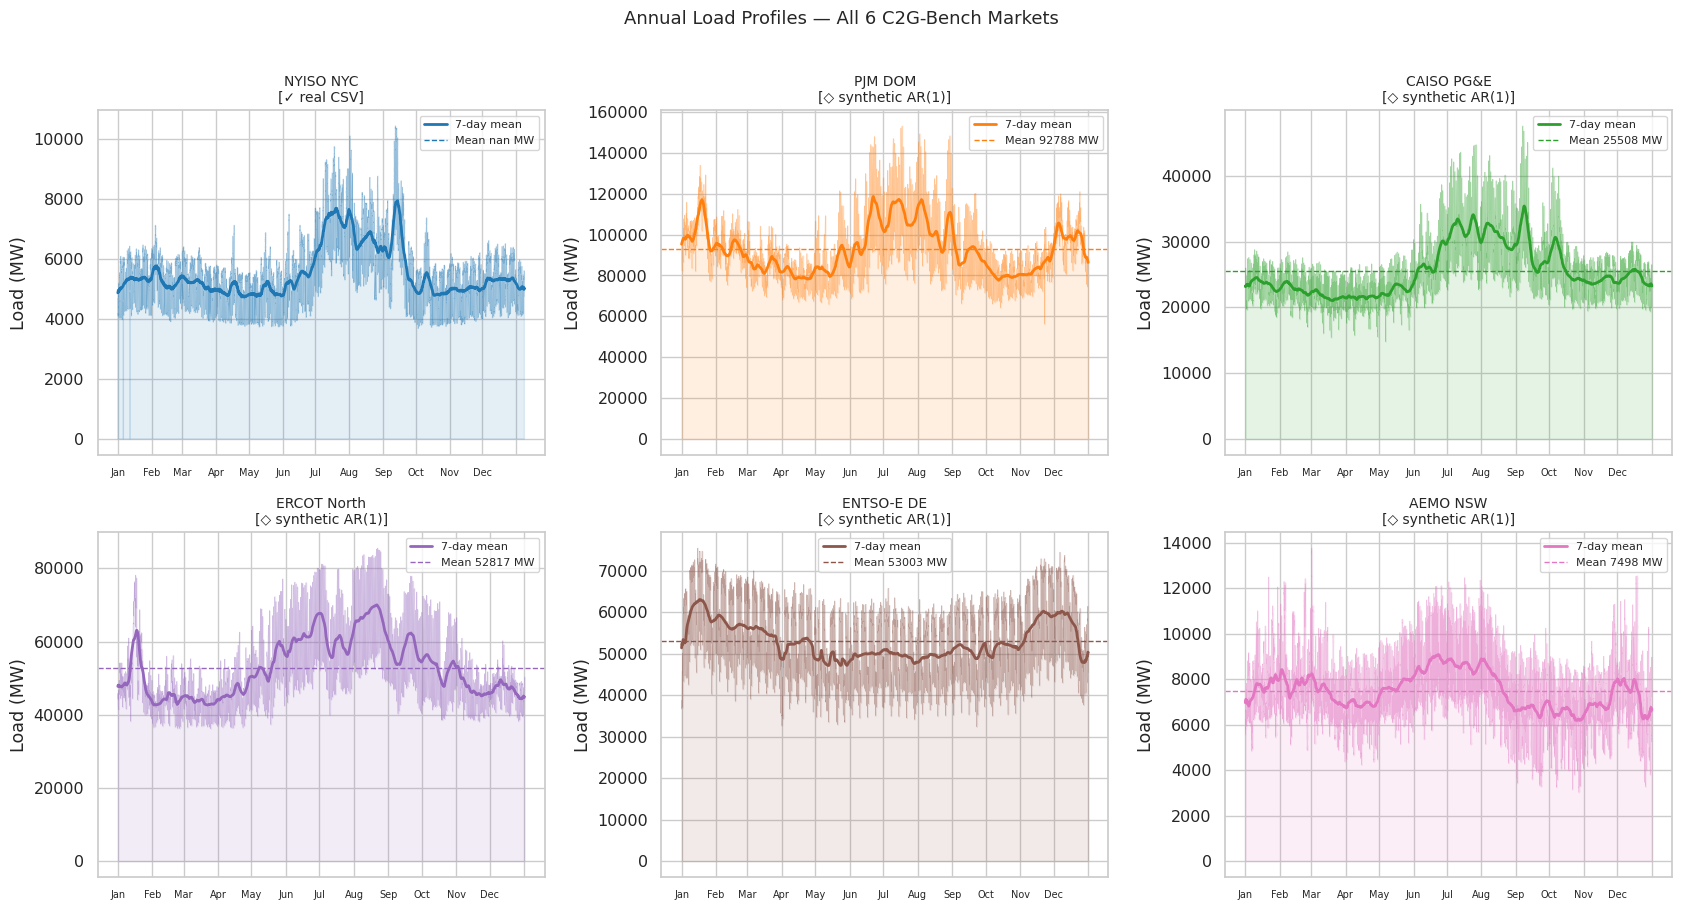

In [3]:
MARKET_CFG = {
    "nyiso_nyc":   ("NYISO NYC",      "#1f77b4", "real",      nyc["load_mw"].values,   nyc["ts"].values),
    "pjm_dom":     ("PJM DOM",        "#ff7f0e", "synthetic", synthetic_load["pjm_dom"], None),
    "caiso_pgae":  ("CAISO PG&E",     "#2ca02c", "synthetic", synthetic_load["caiso_pgae"], None),
    "ercot_north": ("ERCOT North",    "#9467bd", "synthetic", synthetic_load["ercot_north"], None),
    "entso_de":    ("ENTSO-E DE",     "#8c564b", "synthetic", synthetic_load["entso_de"], None),
    "aemo_nsw":    ("AEMO NSW",       "#e377c2", "synthetic", synthetic_load["aemo_nsw"], None),
}

fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharey=False)
month_tick_idx  = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365]
month_names     = ["Jan","Feb","Mar","Apr","May","Jun",
                   "Jul","Aug","Sep","Oct","Nov","Dec",""]
TICKS_PER_DAY_5MIN = 12 * 24   # for synthetic (5-min ticks)
TICKS_PER_DAY_NYISO = 12 * 24  # NYC real data is also 5-min

for ax, (mkt, (label, color, src, loads, ts)) in zip(axes.flat, MARKET_CFG.items()):
    n  = len(loads)
    x  = np.arange(n) / (TICKS_PER_DAY_5MIN if src == "synthetic" else TICKS_PER_DAY_NYISO)

    # 7-day rolling mean
    rol = pd.Series(loads).rolling(7 * TICKS_PER_DAY_5MIN, center=True, min_periods=1).mean().values

    ax.fill_between(x, loads, alpha=0.12, color=color)
    ax.plot(x, loads, lw=0.25, color=color, alpha=0.5)
    ax.plot(x, rol,   lw=2.0,  color=color, label="7-day mean")
    ax.axhline(np.mean(loads), color=color, lw=1, ls="--",
               label=f"Mean {np.mean(loads):.0f} MW")

    # Month tick positions (in days)
    ax.set_xticks(month_tick_idx[:13])
    ax.set_xticklabels(month_names, fontsize=7)
    ax.set_ylabel("Load (MW)")
    badge = "✓ real CSV" if src == "real" else "◇ synthetic AR(1)"
    ax.set_title(f"{label}\n[{badge}]", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("Annual Load Profiles — All 6 C2G-Bench Markets",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGDIR / "fig_energy_annual.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 — Load-duration curve & LMP proxy calibration

The benchmark derives a synthetic LMP from the load-duration curve:
$$\lambda(t) = \lambda_{\text{base}} + s \cdot \max(0,\, L_t - L_{\text{median}}) / 1000$$

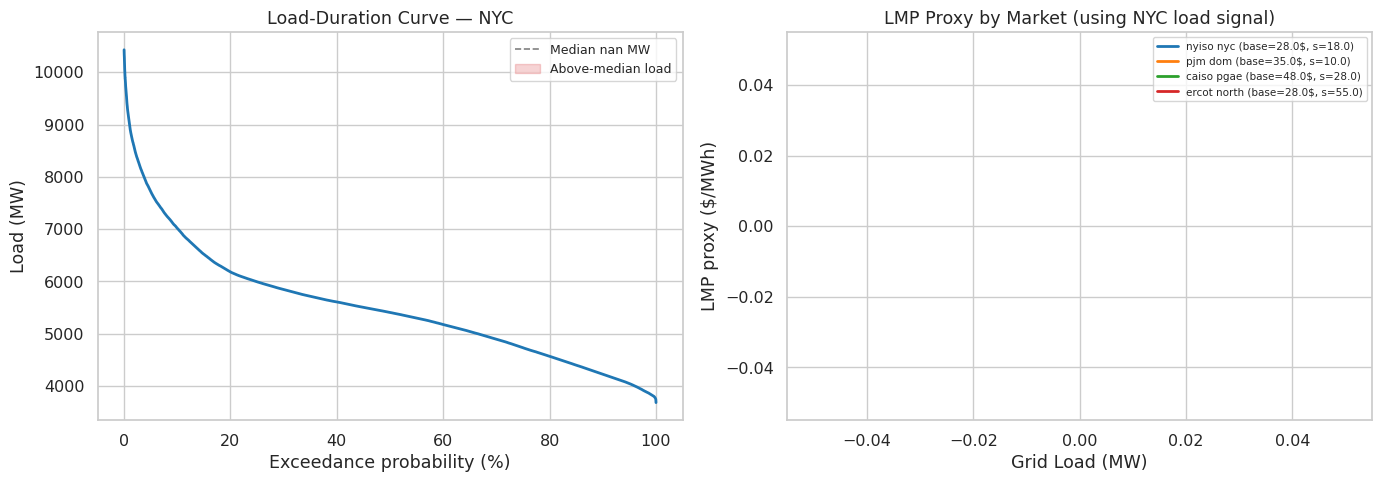

In [4]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Load-duration curve for NYC ──────────────────────────────
ax = axes[0]
sorted_load = np.sort(nyc["load_mw"].values)[::-1]
pct = np.linspace(0, 100, len(sorted_load))
ax.plot(pct, sorted_load, "#1f77b4", lw=2)
L_med = np.median(nyc["load_mw"])
ax.axhline(L_med, color="grey", ls="--", lw=1.2, label=f"Median {L_med:.0f} MW")
ax.fill_between(pct, sorted_load, L_med,
                where=(sorted_load >= L_med), alpha=0.2, color="#d62728",
                label="Above-median load")
ax.set_xlabel("Exceedance probability (%)")
ax.set_ylabel("Load (MW)")
ax.set_title("Load-Duration Curve — NYC")
ax.legend(fontsize=9)

# ── Right: LMP proxy for multiple markets ─────────────────────────
ax2 = axes[1]
L_range = np.linspace(0, nyc["load_mw"].max() * 1.1, 400)

for mkt, color in zip(["nyiso_nyc","pjm_dom","caiso_pgae","ercot_north"],
                       colors[:4]):
    p    = MARKET_PRESETS[mkt]
    lmp  = p.lmp_base_usd + p.lmp_slope_usd * np.maximum(0, L_range - L_med) / 1000
    label = f"{mkt.replace('_',' ')} (base={p.lmp_base_usd}$, s={p.lmp_slope_usd})"
    ax2.plot(L_range, lmp, color=color, lw=2, label=label)

ax2.axvline(L_med, color="grey", ls="--", lw=1)
ax2.set_xlabel("Grid Load (MW)")
ax2.set_ylabel("LMP proxy ($/MWh)")
ax2.set_title("LMP Proxy by Market (using NYC load signal)")
ax2.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig(FIGDIR / "fig_energy_ldc_lmp.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 — Diurnal load patterns: weekday vs weekend

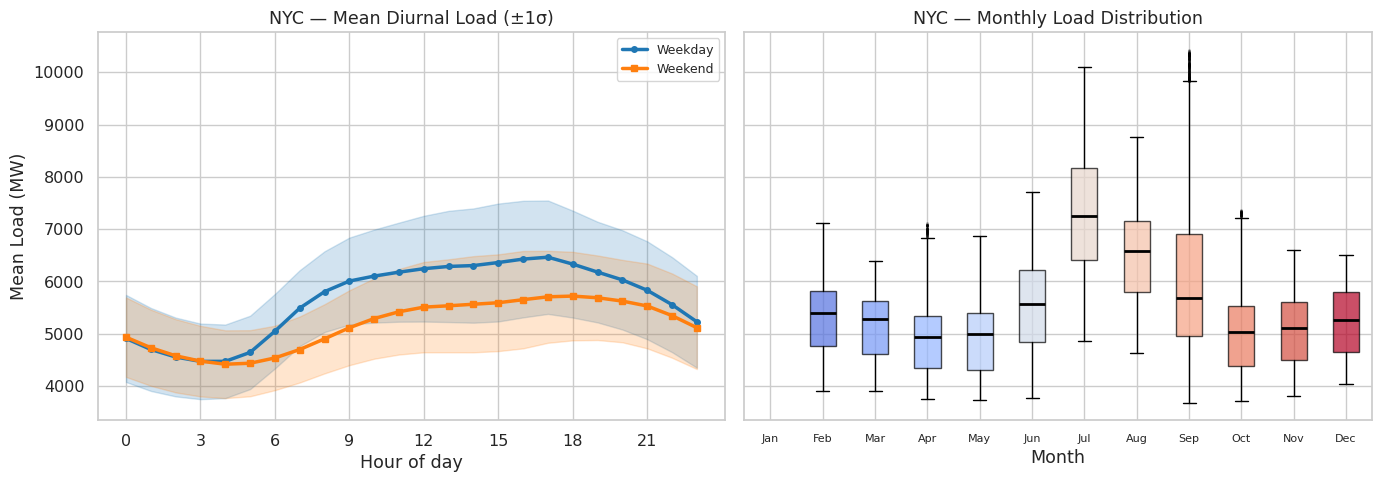

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# Left: hourly profile weekday vs weekend
ax = axes[0]
nyc_wd = nyc[nyc["dow"] < 5].groupby("hour")["load_mw"].agg(["mean","std"]).reset_index()
nyc_we = nyc[nyc["dow"] >= 5].groupby("hour")["load_mw"].agg(["mean","std"]).reset_index()
h = np.arange(24)
ax.fill_between(h, nyc_wd["mean"]-nyc_wd["std"], nyc_wd["mean"]+nyc_wd["std"],
                alpha=0.2, color="#1f77b4")
ax.fill_between(h, nyc_we["mean"]-nyc_we["std"], nyc_we["mean"]+nyc_we["std"],
                alpha=0.2, color="#ff7f0e")
ax.plot(h, nyc_wd["mean"], "#1f77b4", lw=2.5, marker="o", ms=4, label="Weekday")
ax.plot(h, nyc_we["mean"], "#ff7f0e", lw=2.5, marker="s", ms=4, label="Weekend")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean Load (MW)")
ax.set_title("NYC — Mean Diurnal Load (±1σ)")
ax.legend(fontsize=9)
ax.set_xticks(range(0, 24, 3))

# Right: monthly median box
ax2 = axes[1]
month_data = [nyc[nyc["month"] == m]["load_mw"].values for m in range(1, 13)]
bp = ax2.boxplot(month_data, patch_artist=True, medianprops={"color":"k","lw":2},
                 flierprops={"marker":".","ms":2,"alpha":0.3})
for patch, c in zip(bp["boxes"], plt.cm.coolwarm(np.linspace(0, 1, 12))):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax2.set_xticklabels(month_labels, fontsize=8)
ax2.set_xlabel("Month")
ax2.set_title("NYC — Monthly Load Distribution")

plt.tight_layout()
plt.savefig(FIGDIR / "fig_energy_diurnal.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 — Renewable generation profiles

Solar and wind generation at 5-minute and hourly resolution.

solar_hourly: 8,760 rows | cols: ['timestamp_utc', 'ghi_wm2']
wind_hourly: 8,760 rows | cols: ['timestamp_utc', 'wind_speed_100m_ms']
solar_5min: 105,120 rows | cols: ['tick', 'ghi_wm2']
wind_5min: 105,120 rows | cols: ['tick', 'wind_speed_100m_ms']


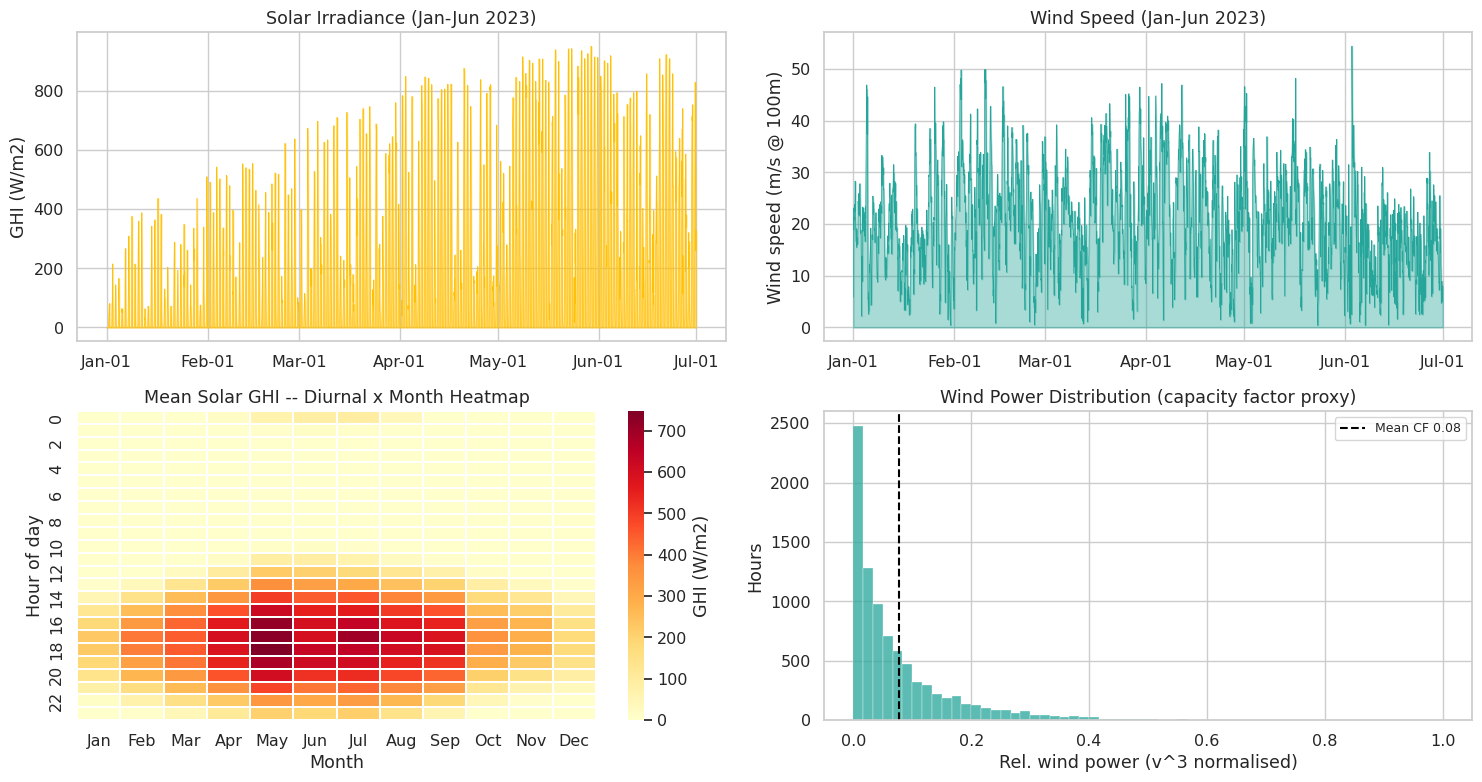

In [6]:
solar_h = pd.read_csv(RENEW / "solar_hourly.csv", parse_dates=["timestamp_utc"])
wind_h  = pd.read_csv(RENEW / "wind_hourly.csv",  parse_dates=["timestamp_utc"])
# 5-min files use tick index, not timestamp — load without parse_dates
solar_5 = pd.read_csv(RENEW / "solar_5min.csv")
wind_5  = pd.read_csv(RENEW / "wind_5min.csv")

for df, name in [(solar_h,"solar_hourly"),(wind_h,"wind_hourly"),
                 (solar_5,"solar_5min"),(wind_5,"wind_5min")]:
    print(f"{name}: {len(df):,} rows | cols: {list(df.columns)}")

month_labels_short = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# ── Solar timeseries (Jan to Jun for clarity) ──
ax = axes[0,0]
s  = solar_h.set_index("timestamp_utc")["ghi_wm2"]
s_sub = s[s.index.month <= 6]
ax.fill_between(s_sub.index, s_sub, alpha=0.4, color="#FFC107")
ax.plot(s_sub.index, s_sub, lw=0.5, color="#FFC107")
ax.set_ylabel("GHI (W/m2)")
ax.set_title("Solar Irradiance (Jan-Jun 2023)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))

# ── Wind timeseries ──
ax = axes[0,1]
w  = wind_h.set_index("timestamp_utc")["wind_speed_100m_ms"]
w_sub = w[w.index.month <= 6]
ax.fill_between(w_sub.index, w_sub, alpha=0.4, color="#26a69a")
ax.plot(w_sub.index, w_sub, lw=0.5, color="#26a69a")
ax.set_ylabel("Wind speed (m/s @ 100m)")
ax.set_title("Wind Speed (Jan-Jun 2023)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))

# ── Solar diurnal mean by month ──
ax = axes[1,0]
solar_h["hour"]  = solar_h["timestamp_utc"].dt.hour
solar_h["month"] = solar_h["timestamp_utc"].dt.month
pivot_s = solar_h.groupby(["month","hour"])["ghi_wm2"].mean().reset_index()
pivot_s = pivot_s.pivot(index="month", columns="hour", values="ghi_wm2")
pivot_s.index = month_labels_short
sns.heatmap(pivot_s.T, ax=ax, cmap="YlOrRd", cbar_kws={"label":"GHI (W/m2)"},
            linewidths=0.2)
ax.set_xlabel("Month")
ax.set_ylabel("Hour of day")
ax.set_title("Mean Solar GHI -- Diurnal x Month Heatmap")

# ── Wind capacity factor distribution ──
ax = axes[1,1]
v_cubed_norm = (w / w.max()) ** 3
ax.hist(v_cubed_norm, bins=60, color="#26a69a", alpha=0.75, edgecolor="white", lw=0.3)
ax.set_xlabel("Rel. wind power (v^3 normalised)")
ax.set_ylabel("Hours")
ax.set_title("Wind Power Distribution (capacity factor proxy)")
ax.axvline(v_cubed_norm.mean(), color="k", ls="--", lw=1.5,
           label="Mean CF " + f"{v_cubed_norm.mean():.2f}")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGDIR / "fig_energy_renewable.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 — MacroGridSignal RegD dispatch & LMP (1-hour simulation)

Simulates the `MacroGridSignal` for each market for 720 ticks (1 hour at 5s),
showing the regulation-D signal and LMP.

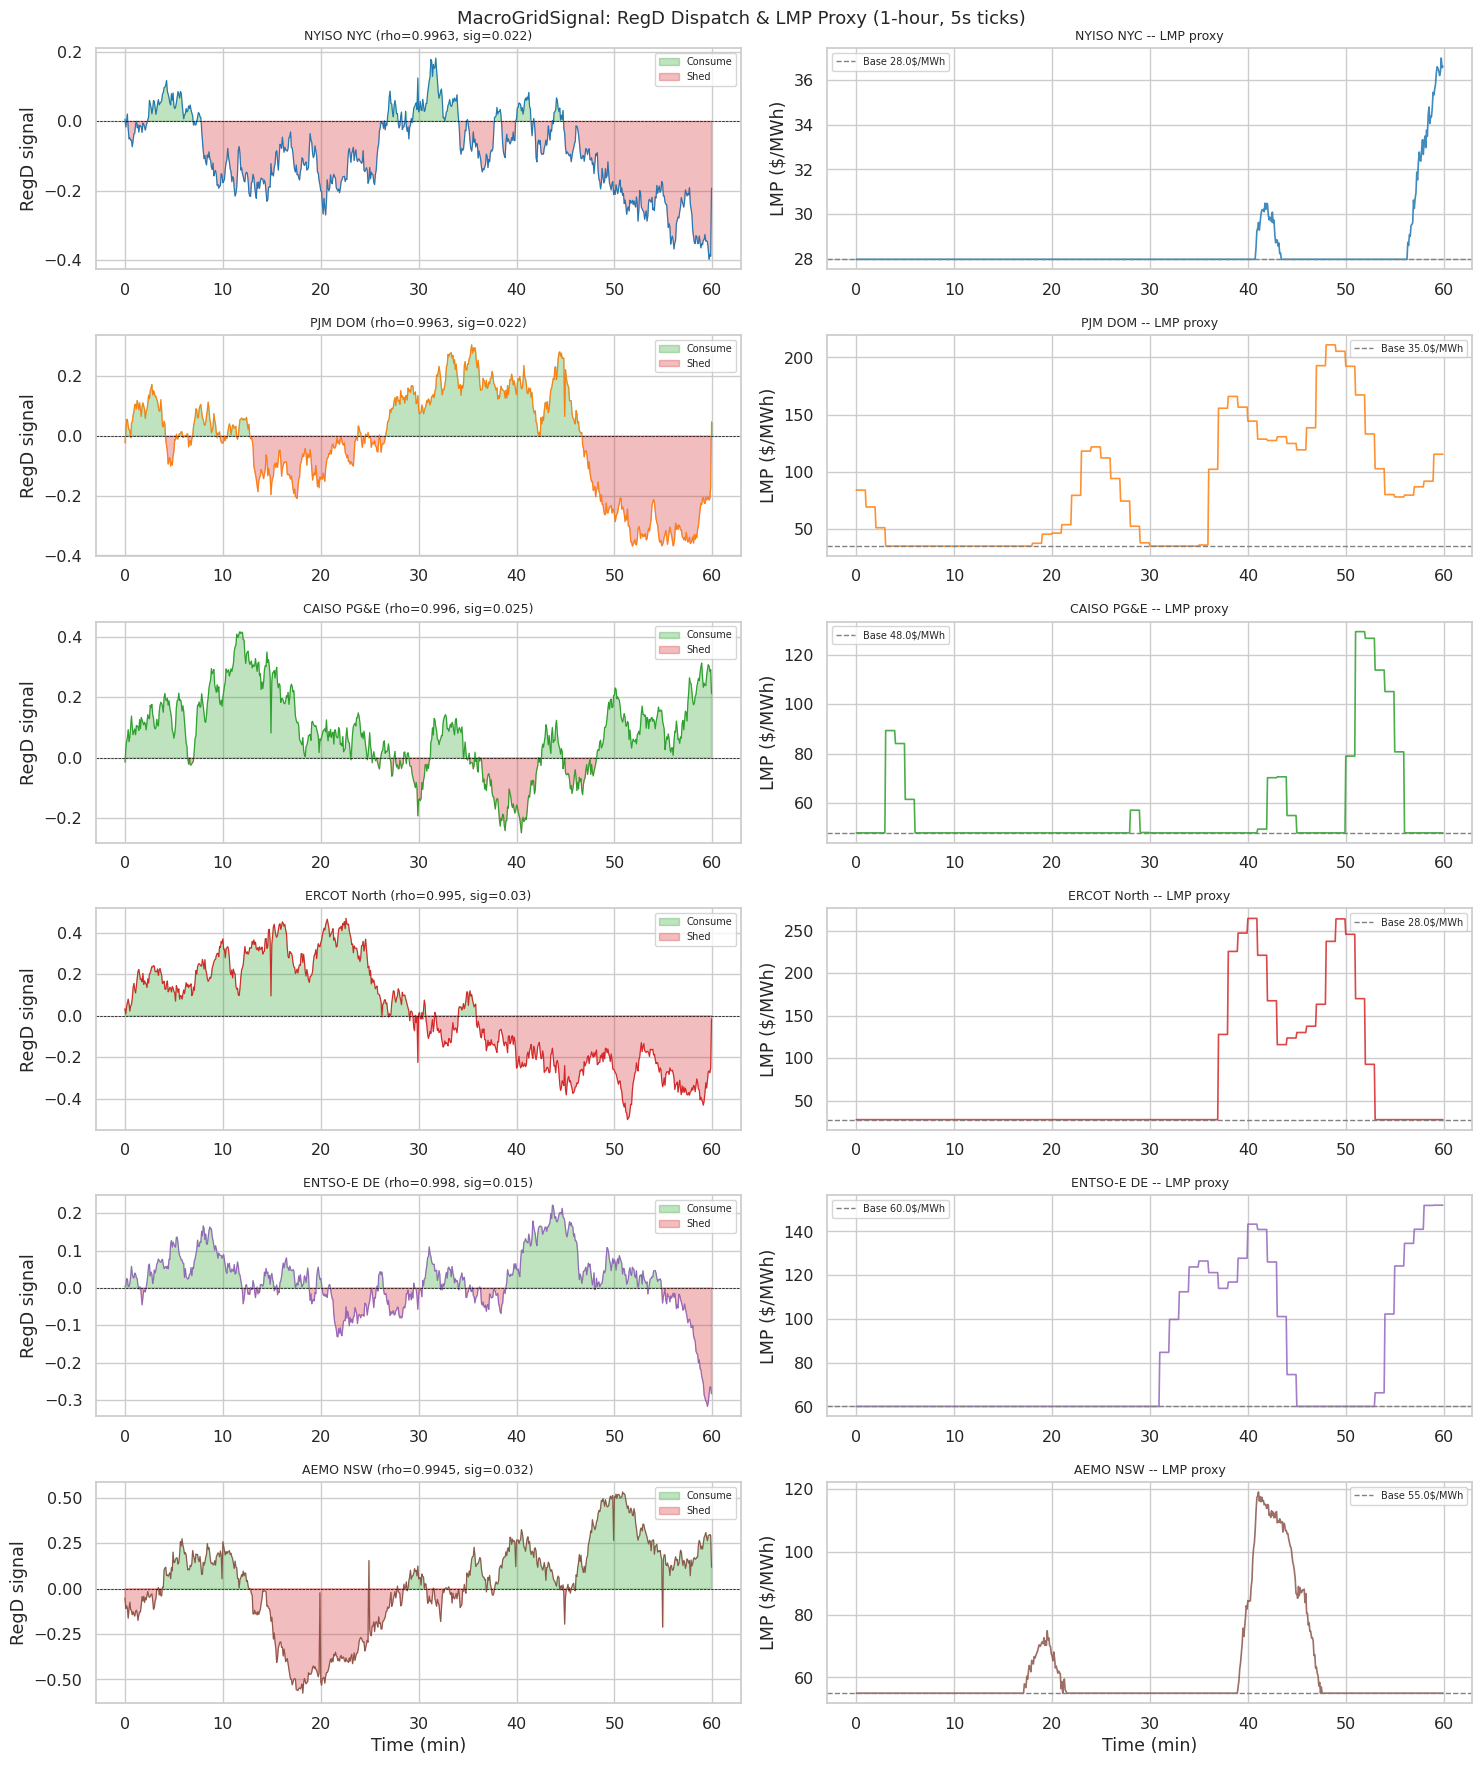

In [7]:
DT = 5
N  = 720   # 1 hour at 5s ticks

market_keys = list(MARKET_PRESETS.keys())
market_labels_m = {
    "nyiso_nyc":   "NYISO NYC",
    "pjm_dom":     "PJM DOM",
    "caiso_pgae":  "CAISO PG&E",
    "ercot_north": "ERCOT North",
    "entso_de":    "ENTSO-E DE",
    "aemo_nsw":    "AEMO NSW",
}
colors_m = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, axes = plt.subplots(len(market_keys), 2, figsize=(15, 3*len(market_keys)),
                          sharex=False)

for i, (mkt, color) in enumerate(zip(market_keys, colors_m)):
    # Each market gets a distinct seed so the AR(1) noise sequences differ.
    # (Using a single seed=42 for every market produced identical RegD traces
    # because rho values are nearly equal across presets.)
    market_seed = 42 + i * 17
    sig = MacroGridSignal(energy_dir=str(ENERGY), market=mkt, dt_seconds=DT, seed=market_seed)
    sig.reset()

    regs, lmps = [], []
    for t in range(N):
        obs = sig.step()
        regs.append(obs["regd_signal"])
        lmps.append(obs["lmp_usd_mwh"])

    ticks = np.arange(N) * DT / 60   # minutes
    p = MARKET_PRESETS[mkt]

    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    # RegD
    regs_arr = np.array(regs)
    ax1.plot(ticks, regs_arr, color=color, lw=0.8)
    ax1.axhline(0, color="k", lw=0.5, ls="--")
    ax1.fill_between(ticks, regs_arr, 0, where=regs_arr>=0,
                     alpha=0.3, color="#2ca02c", label="Consume")
    ax1.fill_between(ticks, regs_arr, 0, where=regs_arr<0,
                     alpha=0.3, color="#d62728", label="Shed")
    ax1.set_ylabel("RegD signal")
    title1 = market_labels_m[mkt] + " (rho=" + str(p.regd_rho) + ", sig=" + str(p.regd_sigma) + ")"
    ax1.set_title(title1, fontsize=9)
    ax1.legend(fontsize=7, loc="upper right")
    if i == len(market_keys)-1:
        ax1.set_xlabel("Time (min)")

    # LMP
    ax2.plot(ticks, lmps, color=color, lw=1.2, alpha=0.85)
    ax2.axhline(p.lmp_base_usd, color="grey", ls="--", lw=1,
                label="Base " + str(p.lmp_base_usd) + "$/MWh")
    ax2.set_ylabel("LMP ($/MWh)")
    ax2.set_title(market_labels_m[mkt] + " -- LMP proxy", fontsize=9)
    ax2.legend(fontsize=7)
    if i == len(market_keys)-1:
        ax2.set_xlabel("Time (min)")

fig.suptitle("MacroGridSignal: RegD Dispatch & LMP Proxy (1-hour, 5s ticks)",
             fontsize=13)
plt.tight_layout()
plt.savefig(FIGDIR / "fig_energy_macrogrid.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 — Energy × Weather joint analysis (NYC, 2023–2024)

Merge NYC 5-minute load with hourly NOAA ISD temperature and examine
the load–temperature relationship and cooling degree-days.

Pattern-joined rows: 288 (12 months x 24 hours = 288 bins)


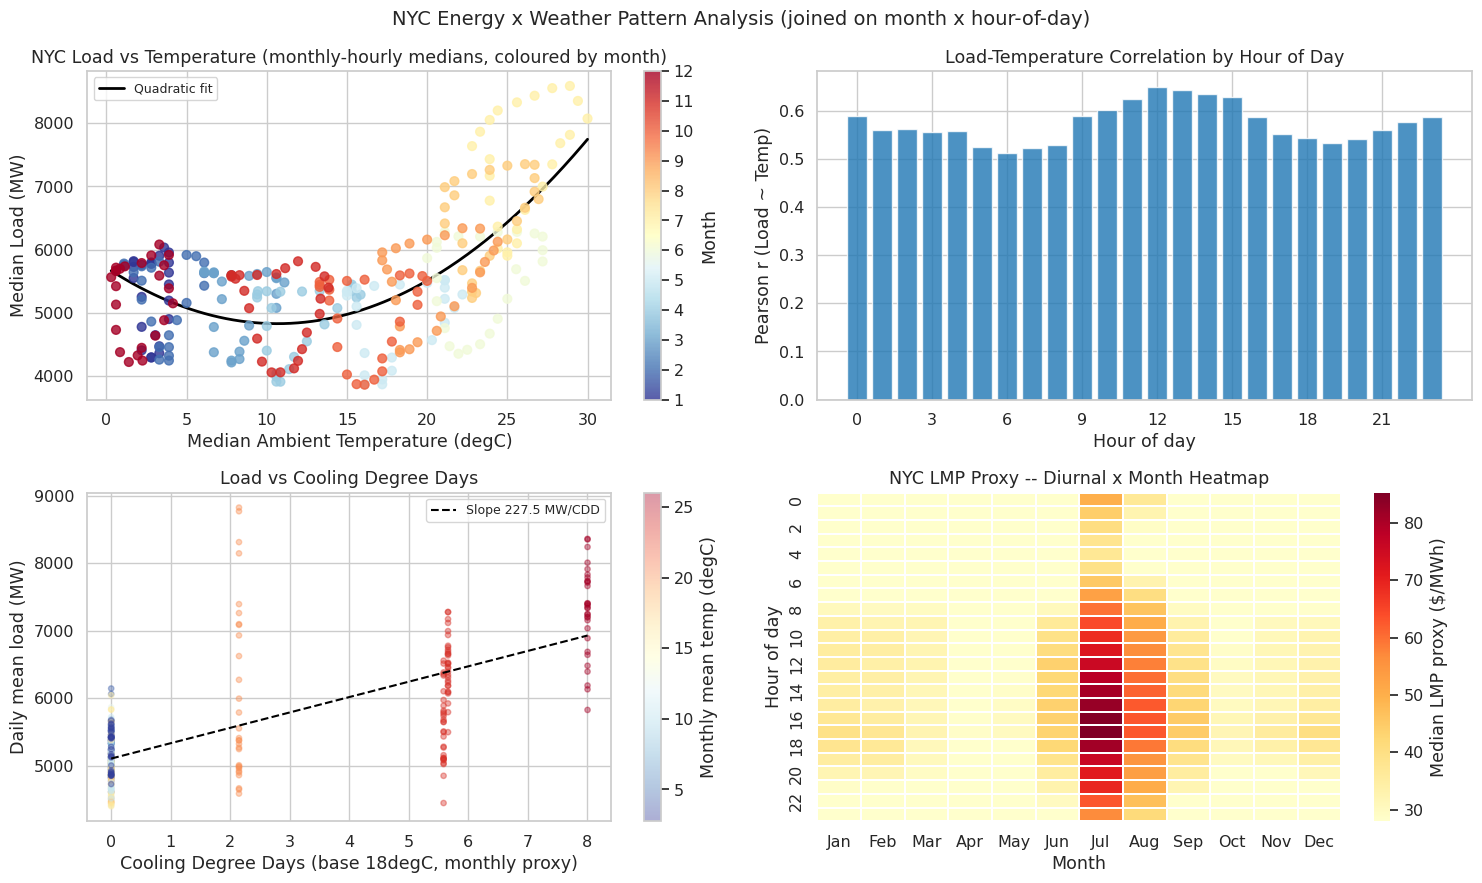

Overall Load-Temp correlation (monthly-hourly medians): 0.446


In [8]:
# Energy: 2023  |  Weather: 2024  — different years.
# Join on (month, hour-of-day) median to capture seasonal/diurnal patterns.
weather_nyc = pd.read_csv(WEATHER / "NYC.csv", parse_dates=["timestamp_utc"])
weather_nyc["timestamp_utc"] = weather_nyc["timestamp_utc"].dt.tz_localize(None)
weather_nyc["month"] = weather_nyc["timestamp_utc"].dt.month
weather_nyc["hour"]  = weather_nyc["timestamp_utc"].dt.hour

nyc2 = nyc.copy()
nyc2["month"] = nyc2["ts"].dt.month
nyc2["hour"]  = nyc2["ts"].dt.hour

# Median temperature per (month, hour) from weather
w_agg = weather_nyc.groupby(["month","hour"])["temp_c"].median().reset_index()

# Median load per (month, hour) from energy
e_agg = nyc2.groupby(["month","hour"])["load_mw"].median().reset_index()

merged = e_agg.merge(w_agg, on=["month","hour"])
print(f"Pattern-joined rows: {len(merged):,} (12 months x 24 hours = 288 bins)")

month_labels_short = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# ── Scatter: median load vs median temperature ──
ax = axes[0,0]
sc = ax.scatter(merged["temp_c"], merged["load_mw"],
                c=merged["month"], cmap="RdYlBu_r",
                alpha=0.8, s=40, zorder=5)
plt.colorbar(sc, ax=ax, label="Month", ticks=range(1,13))
m_coef = np.polyfit(merged["temp_c"], merged["load_mw"], deg=2)
t_fit  = np.linspace(merged["temp_c"].min(), merged["temp_c"].max(), 200)
ax.plot(t_fit, np.polyval(m_coef, t_fit), "k-", lw=2, label="Quadratic fit")
ax.set_xlabel("Median Ambient Temperature (degC)")
ax.set_ylabel("Median Load (MW)")
ax.set_title("NYC Load vs Temperature (monthly-hourly medians, coloured by month)")
ax.legend(fontsize=9)

# ── Correlation by hour ───────────────────────────────────────────
ax2 = axes[0,1]
hourly_corr = merged.groupby("hour").apply(
    lambda g: g["load_mw"].corr(g["temp_c"])
).reset_index(name="corr")
ax2.bar(hourly_corr["hour"], hourly_corr["corr"],
        color="#1f77b4", alpha=0.8, edgecolor="white")
ax2.axhline(0, color="k", lw=0.8)
ax2.set_xlabel("Hour of day")
ax2.set_ylabel("Pearson r (Load ~ Temp)")
ax2.set_title("Load-Temperature Correlation by Hour of Day")
ax2.set_xticks(range(0, 24, 3))

# ── Cooling degree days (CDD) vs load ────────────────────────────
ax3 = axes[1,0]
BASE_C = 18
daily_e = nyc2.copy()
daily_e["date"] = daily_e["ts"].dt.date
daily_e_agg = daily_e.groupby("date").agg(load_mean=("load_mw","mean"),
                                           month=("month","first"),
                                           hour=("hour","first")).reset_index()
daily_w = weather_nyc.copy()
daily_w["date_approx"] = daily_w.apply(
    lambda r: pd.Timestamp(f"2023-{r['month']:02d}-15"), axis=1)
monthly_temp = weather_nyc.groupby("month")["temp_c"].mean().reset_index()
monthly_temp.columns = ["month","temp_mean"]
daily_e_agg2 = daily_e_agg.merge(monthly_temp, on="month")
daily_e_agg2["cdd"] = np.maximum(0, daily_e_agg2["temp_mean"] - BASE_C)

c3 = ax3.scatter(daily_e_agg2["cdd"], daily_e_agg2["load_mean"],
                 alpha=0.4, s=15, c=daily_e_agg2["temp_mean"], cmap="RdYlBu_r")
plt.colorbar(c3, ax=ax3, label="Monthly mean temp (degC)")
ax3.set_xlabel("Cooling Degree Days (base " + str(BASE_C) + "degC, monthly proxy)")
ax3.set_ylabel("Daily mean load (MW)")
ax3.set_title("Load vs Cooling Degree Days")
m3 = np.polyfit(daily_e_agg2["cdd"], daily_e_agg2["load_mean"], 1)
cdd_fit = np.linspace(0, daily_e_agg2["cdd"].max(), 100)
ax3.plot(cdd_fit, np.polyval(m3, cdd_fit), "k--", lw=1.5,
         label="Slope " + f"{m3[0]:.1f}" + " MW/CDD")
ax3.legend(fontsize=9)

# ── LMP proxy heatmap ─────────────────────────────────────────────
ax4 = axes[1,1]
L_med = nyc2["load_mw"].median()
nyc2["lmp_proxy"] = 28.0 + 18.0 * np.maximum(0, nyc2["load_mw"] - L_med) / 1000
pivot_lmp = (nyc2.groupby(["month","hour"])["lmp_proxy"].median()
             .reset_index()
             .pivot(index="month", columns="hour", values="lmp_proxy"))
pivot_lmp.index = month_labels_short
sns.heatmap(pivot_lmp.T, ax=ax4, cmap="YlOrRd", fmt=".0f",
            cbar_kws={"label": "Median LMP proxy ($/MWh)"}, linewidths=0.2)
ax4.set_xlabel("Month")
ax4.set_ylabel("Hour of day")
ax4.set_title("NYC LMP Proxy -- Diurnal x Month Heatmap")

fig.suptitle("NYC Energy x Weather Pattern Analysis (joined on month x hour-of-day)", fontsize=14)
plt.tight_layout()
plt.savefig(FIGDIR / "fig_energy_weather_joint.png", dpi=150, bbox_inches="tight")
plt.show()
print("Overall Load-Temp correlation (monthly-hourly medians):",
      f"{merged['load_mw'].corr(merged['temp_c']):.3f}")